# ETL

In [2]:
import pandas as pd
import seaborn as sns

Carregando datasets

In [4]:
veiculos = pd.read_csv("C:/Users/mathe/Documents/projetos/Analise de dados/projeto-20/paranaiba-transportes/dataset/veiculos.csv")

In [5]:
rotas = pd.read_csv("C:/Users/mathe/Documents/projetos/Analise de dados/projeto-20/paranaiba-transportes/dataset/rotas.csv")

In [6]:
entregas = pd.read_csv("C:/Users/mathe/Documents/projetos/Analise de dados/projeto-20/paranaiba-transportes/dataset/entregas.csv")

In [7]:
manutencao = pd.read_csv("C:/Users/mathe/Documents/projetos/Analise de dados/projeto-20/paranaiba-transportes/dataset/manutencao.csv")

# Veiculos

In [9]:
veiculos.head()

,Número_caminhao,marca,Ano,Km_rodados,tipo
0,1001,Scania,2023-12-21 17:13:03.684174464,276675,articulado
1,1002,Volvo,2023-04-23 06:43:39.735883136,61358,articulado
2,1003,Scania,2015-10-19 08:07:16.239027664,531097,rígido
3,1004,Mercedes,2012-08-24 04:39:10.018144392,692274,rígido
4,1005,Volvo,2017-07-10 20:37:34.525778720,564678,articulado


In [10]:
veiculos.tail()

,Número_caminhao,marca,Ano,Km_rodados,tipo
95,1096,Volvo,2015-11-19 00:42:40.658100176,554298,rígido
96,1097,Scania,2020-03-13 13:01:18.227046976,86630,rígido
97,1098,Volvo,2017-05-17 11:43:52.253323296,307517,articulado
98,1099,Mercedes,2013-05-08 17:09:48.751715504,678785,rígido
99,10100,Scania,2018-06-03 04:02:52.473119552,502073,articulado


Visualizando estrutra do dataset

In [12]:
veiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Número_caminhao  100 non-null    int64 
 1   marca            100 non-null    object
 2   Ano              100 non-null    object
 3   Km_rodados       100 non-null    int64 
 4   tipo             100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [13]:
veiculos.isnull().sum()

Número_caminhao    0
marca              0
Ano                0
Km_rodados         0
tipo               0
dtype: int64

In [14]:
veiculos.duplicated().sum()

0

In [15]:
veiculos['Número_caminhao'].duplicated().sum()

0

Corrigindo coluna ano

In [17]:
veiculos['Ano'] = pd.to_datetime(veiculos['Ano']).dt.date

In [18]:
veiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Número_caminhao  100 non-null    int64 
 1   marca            100 non-null    object
 2   Ano              100 non-null    object
 3   Km_rodados       100 non-null    int64 
 4   tipo             100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [19]:
veiculos.head()

,Número_caminhao,marca,Ano,Km_rodados,tipo
0,1001,Scania,2023-12-21,276675,articulado
1,1002,Volvo,2023-04-23,61358,articulado
2,1003,Scania,2015-10-19,531097,rígido
3,1004,Mercedes,2012-08-24,692274,rígido
4,1005,Volvo,2017-07-10,564678,articulado


In [35]:
veiculos['Ano'] = pd.to_datetime(veiculos['Ano'])

In [37]:
veiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Número_caminhao  100 non-null    int64         
 1   marca            100 non-null    object        
 2   Ano              100 non-null    datetime64[ns]
 3   Km_rodados       100 non-null    int64         
 4   tipo             100 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 4.0+ KB


Verificando outliers 

<Axes: xlabel='Km_rodados'>

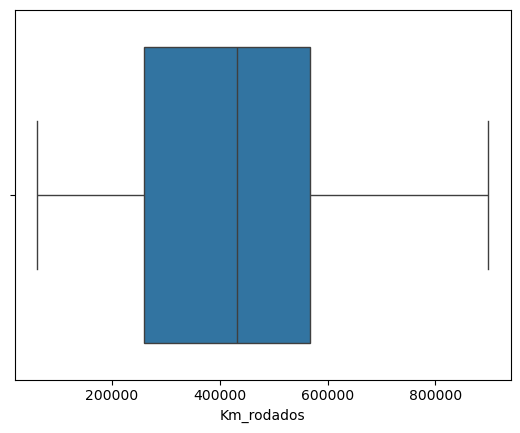

In [47]:
sns.boxplot(data=veiculos, x='Km_rodados')

In [50]:
veiculos['Km_rodados'].describe()

count       100.000000
mean     440307.610000
std      230192.164358
min       61358.000000
25%      259550.750000
50%      431093.000000
75%      567749.250000
max      898371.000000
Name: Km_rodados, dtype: float64

In [58]:
veiculos.to_csv("C:/Users/mathe/Documents/projetos/Analise de dados/projeto-20/paranaiba-transportes/dataset/veiculos-v1.csv")

# Dataset rotas

In [53]:
rotas.head()

,Unnamed: 0,Número_Caminhão,rotas,Distância_km,Tempo_estimado_horas,Tipo_De_Carga,Frequência
0,0,1001,Uberlândia-Catalão,190,2.375,consumo,díaria
1,1,1002,Uberlândia-Araguari,30,0.375,industrial,díaria
2,2,1003,Uberlândia-Uberaba,110,1.375,consumo,mensal
3,3,1004,Uberlândia-Goiânia,330,4.125,agrícola,díaria
4,4,1005,Uberlândia-Araguari,30,0.375,agrícola,díaria


In [60]:
rotas.tail()

,Unnamed: 0,Número_Caminhão,rotas,Distância_km,Tempo_estimado_horas,Tipo_De_Carga,Frequência
95,95,1096,Uberlândia-Ribeirão_Preto,300,3.7500,agrícola,díaria
96,96,1097,Uberlândia-Belo_Horizonte,540,6.7500,agrícola,mensal
97,97,1098,Uberlândia-Rio_de_Janeiro,985,12.3125,industrial,díaria
98,98,1099,Uberlândia-Brasília,430,5.3750,agrícola,mensal
99,99,10100,Uberlândia-São_Paulo,585,7.3125,industrial,mensal


Verificando estrutura do dataset

In [63]:
rotas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            100 non-null    int64  
 1   Número_Caminhão       100 non-null    int64  
 2   rotas                 100 non-null    object 
 3   Distância_km          100 non-null    int64  
 4   Tempo_estimado_horas  100 non-null    float64
 5   Tipo_De_Carga         100 non-null    object 
 6   Frequência            100 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.6+ KB


Arendondando tempo estimado

In [66]:
rotas['Tempo_estimado_horas'] = rotas['Tempo_estimado_horas'].round(2)

In [68]:
rotas.head()

,Unnamed: 0,Número_Caminhão,rotas,Distância_km,Tempo_estimado_horas,Tipo_De_Carga,Frequência
0,0,1001,Uberlândia-Catalão,190,2.38,consumo,díaria
1,1,1002,Uberlândia-Araguari,30,0.38,industrial,díaria
2,2,1003,Uberlândia-Uberaba,110,1.38,consumo,mensal
3,3,1004,Uberlândia-Goiânia,330,4.12,agrícola,díaria
4,4,1005,Uberlândia-Araguari,30,0.38,agrícola,díaria


In [70]:
rotas.tail()

,Unnamed: 0,Número_Caminhão,rotas,Distância_km,Tempo_estimado_horas,Tipo_De_Carga,Frequência
95,95,1096,Uberlândia-Ribeirão_Preto,300,3.75,agrícola,díaria
96,96,1097,Uberlândia-Belo_Horizonte,540,6.75,agrícola,mensal
97,97,1098,Uberlândia-Rio_de_Janeiro,985,12.31,industrial,díaria
98,98,1099,Uberlândia-Brasília,430,5.38,agrícola,mensal
99,99,10100,Uberlândia-São_Paulo,585,7.31,industrial,mensal


Verificando Outliers

<Axes: xlabel='Distância_km'>

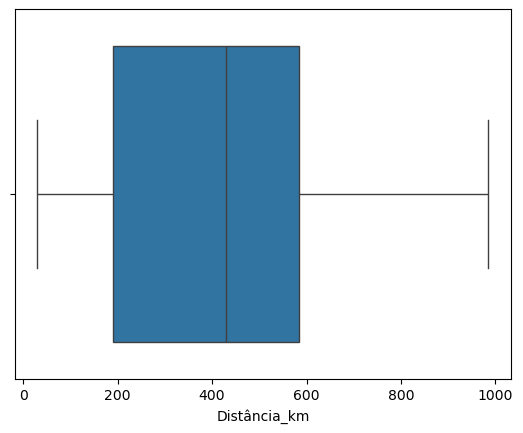

In [77]:
sns.boxplot(data=rotas, x='Distância_km')

In [79]:
rotas['Distância_km'].describe()

count    100.000000
mean     437.100000
std      278.196918
min       30.000000
25%      190.000000
50%      430.000000
75%      585.000000
max      985.000000
Name: Distância_km, dtype: float64

<Axes: xlabel='Tempo_estimado_horas'>

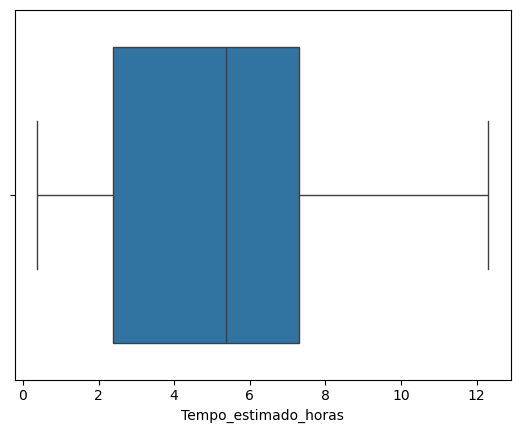

In [81]:
sns.boxplot(data=rotas, x='Tempo_estimado_horas')

In [83]:
rotas['Tempo_estimado_horas'].describe()

count    100.000000
mean       5.464700
std        3.475149
min        0.380000
25%        2.380000
50%        5.380000
75%        7.310000
max       12.310000
Name: Tempo_estimado_horas, dtype: float64